## sat sept 10 trying imcorr again

In [1]:
from pathlib import Path

dem_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/DEMs_Case_Knuth_2024')
ortho_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/Orthos_Case_Knuth_2024')

print("DEMs:")
for f in sorted(dem_dir.glob('*')):
    print(' ', f.name)

print("\nOrthos:")
for f in sorted(ortho_dir.glob('*')):
    print(' ', f.name)

DEMs:
  1954-07-22_2_re-coregistered.tif
  1967-08-03_2_re-coregistered.tif
  1983-09-05_2_re-coregistered.tif
  1989-08-30_3_re-coregistered.tif
  1994-08-25_2_re-coregistered.tif
  2001-08-25_2_re-coregistered.tif

Orthos:
  1967-08-03_ortho.tif
  1979-09-12_sub_cluster_0_ortho.tif
  1979-09-12_sub_cluster_1_ortho.tif
  1979-09-12_sub_cluster_2_ortho.tif
  1983-09-05_ortho.tif
  1983-09-10_ortho.tif
  1983-09-16_sub_cluster_0_ortho.tif
  1983-09-16_sub_cluster_1_ortho.tif
  1989-08-06_ortho.tif
  1989-08-30_ortho.tif
  1989-09-01_ortho.tif
  1989-09-03_ortho.tif
  2001-08-25_ortho.tif
  2002-08-18_ortho.tif


In [6]:
import subprocess
import rasterio
from pathlib import Path

ortho_dir = Path('/Users/milliespencer/Downloads/OneDrive_1_8-4-2026/Orthos_Case_Knuth_2024')
out_dir = Path('/Users/milliespencer/WUS_rock_glaciers/teton_imcorr')

offsets = {
    '1983': (-1.38,  4.16),
    '1989': ( 0.76, -0.60),
    '2001': (-0.40,  2.46),
}

orthos = {
    '1983': ortho_dir / '1983-09-05_ortho.tif',
    '1989': ortho_dir / '1989-08-30_ortho.tif',
    '2001': ortho_dir / '2001-08-25_ortho.tif',
}

west, south, east, north = 510862.6851068522, 4852042.487599996, 513018.6851068522, 4853729.487599996
target_res = 3.5  # resample to coarsest resolution

for year, (dx, dy) in offsets.items():
    inp = orthos[year]
    shifted = out_dir / f'{year}_ortho_shifted.tif'
    out = out_dir / f'{year}_ortho_coreg_aligned.tif'

    with rasterio.open(inp) as src:
        b = src.bounds
        new_left  = b.left   + dx
        new_top   = b.top    + dy
        new_right = b.right  + dx
        new_bot   = b.bottom + dy

    subprocess.run([
        'gdal_translate',
        '-a_ullr', str(new_left), str(new_top), str(new_right), str(new_bot),
        str(inp), str(shifted)
    ], capture_output=True)

    subprocess.run([
        'gdalwarp',
        '-te', str(west), str(south), str(east), str(north),
        '-tr', str(target_res), str(target_res),
        '-r', 'average',
        '-t_srs', 'EPSG:32612',
        '-overwrite',
        str(shifted), str(out)
    ], capture_output=True)

    with rasterio.open(out) as src:
        print(f"{year}: {src.width}x{src.height} px, res={src.res[0]:.2f}m, bounds={src.bounds}")

print("\nFiles ready for IMCORR:")
for f in sorted(out_dir.glob('*ortho_coreg_aligned*')):
    print(f"  {f.name}")

1983: 616x482 px, res=3.50m, bounds=BoundingBox(left=510862.6851068522, bottom=4852042.487599996, right=513018.6851068522, top=4853729.487599996)
1989: 616x482 px, res=3.50m, bounds=BoundingBox(left=510862.6851068522, bottom=4852042.487599996, right=513018.6851068522, top=4853729.487599996)
2001: 616x482 px, res=3.50m, bounds=BoundingBox(left=510862.6851068522, bottom=4852042.487599996, right=513018.6851068522, top=4853729.487599996)

Files ready for IMCORR:
  1983_ortho_coreg_aligned.tif
  1989_ortho_coreg_aligned.tif
  2001_ortho_coreg_aligned.tif


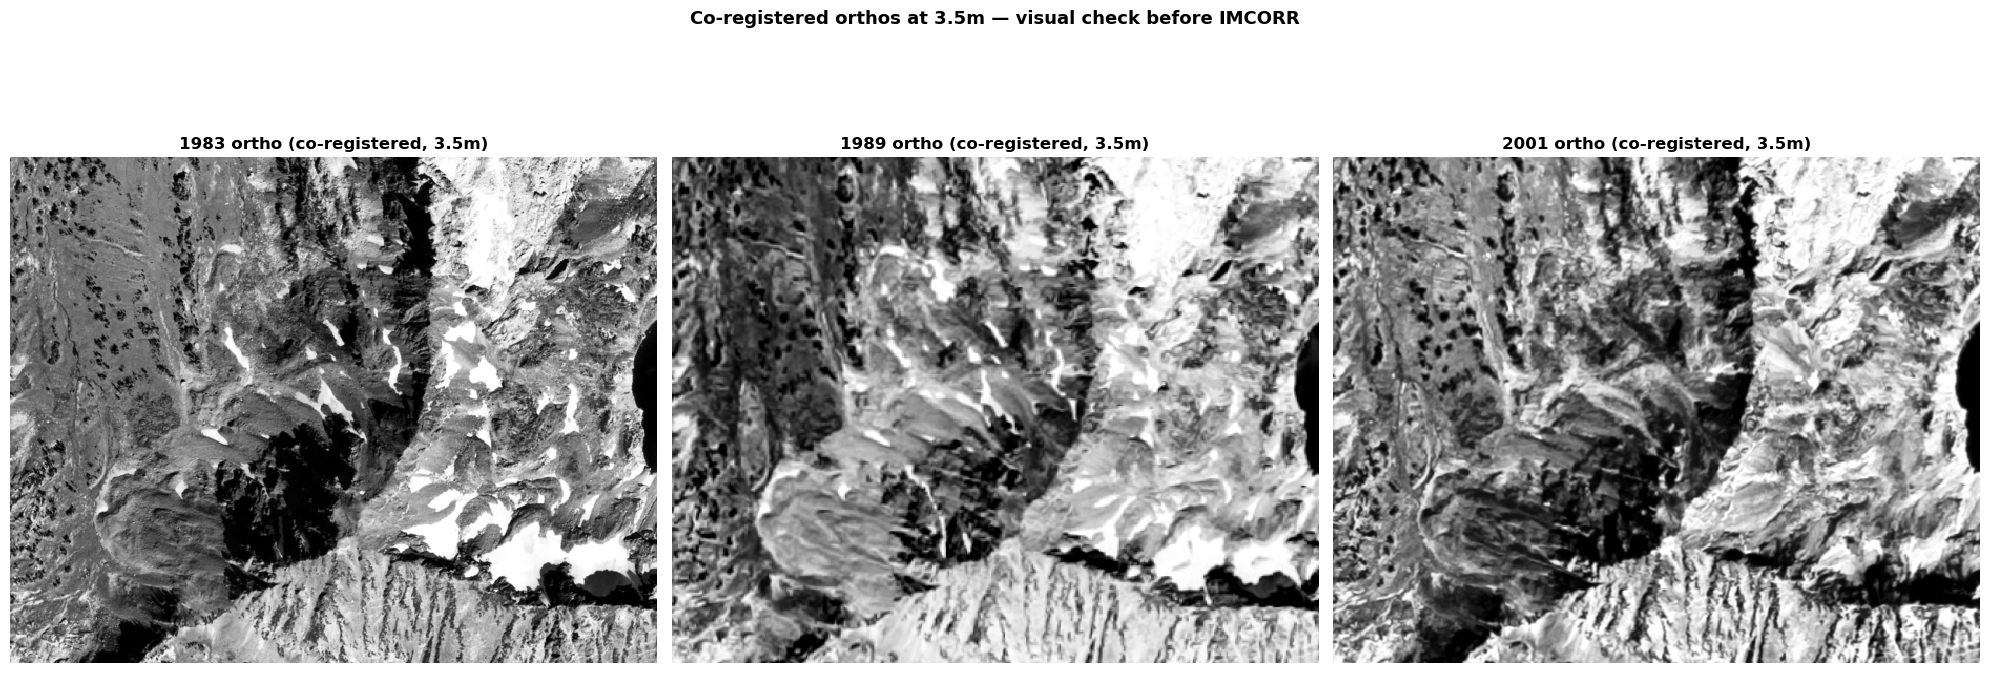

In [10]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, year in zip(axes, ['1983', '1989', '2001']):
    with rasterio.open(out_dir / f'{year}_ortho_coreg_aligned.tif') as src:
        img = src.read(1).astype(np.float32)
        nodata = src.nodata
        if nodata is not None:
            img[img == nodata] = np.nan

    p2, p98 = np.nanpercentile(img, [2, 98])
    img_s = np.clip((img - p2) / (p98 - p2), 0, 1)
    ax.imshow(img_s, cmap='gray', interpolation='nearest')
    ax.set_title(f'{year} ortho (co-registered, 3.5m)', fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Co-registered orthos at 3.5m — visual check before IMCORR',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'ortho_coreg_35m_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Rock glacier polygons overlapping ortho extent: 3


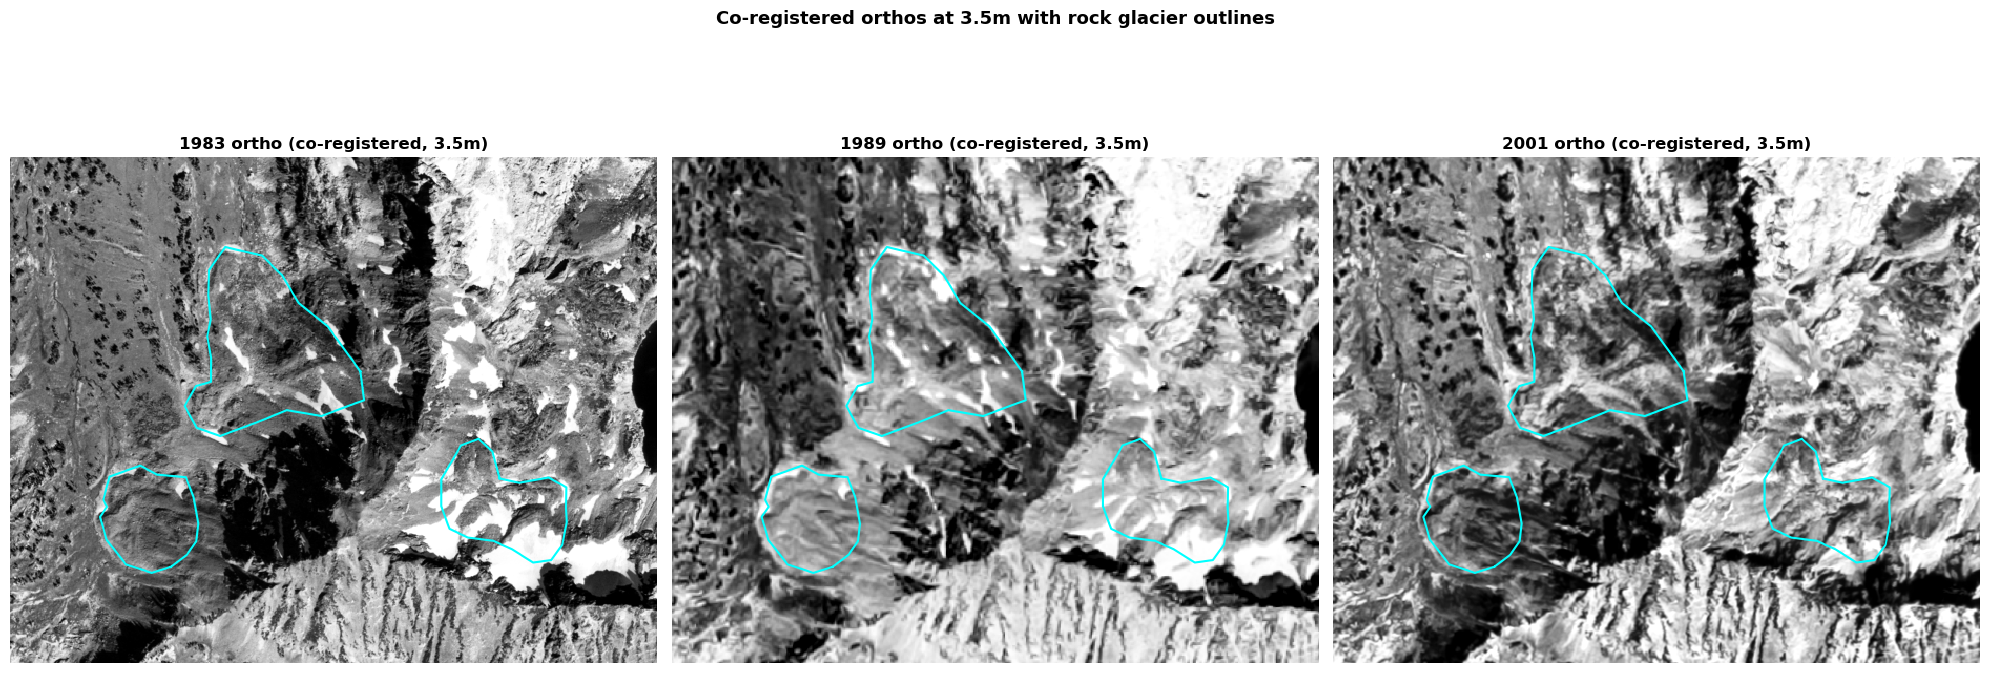

In [11]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import box
from rasterio.transform import array_bounds

# Load buffered rock glaciers and clip to ortho extent
gdf_buf = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp').to_crs('EPSG:32612')
ortho_box = box(west, south, east, north)
gdf_overlap = gdf_buf[gdf_buf.intersects(ortho_box)].copy()
print(f"Rock glacier polygons overlapping ortho extent: {len(gdf_overlap)}")

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, year in zip(axes, ['1983', '1989', '2001']):
    with rasterio.open(out_dir / f'{year}_ortho_coreg_aligned.tif') as src:
        img = src.read(1).astype(np.float32)
        nodata = src.nodata
        transform = src.transform
        if nodata is not None:
            img[img == nodata] = np.nan

    p2, p98 = np.nanpercentile(img, [2, 98])
    img_s = np.clip((img - p2) / (p98 - p2), 0, 1)

    extent = [west, east, south, north]
    ax.imshow(img_s, cmap='gray', extent=extent, interpolation='nearest', origin='upper')

    # Overlay rock glacier polygons
    for geom in gdf_overlap.geometry:
        xs, ys = geom.exterior.xy
        ax.plot(xs, ys, color='cyan', linewidth=1.5, zorder=3)

    ax.set_title(f'{year} ortho (co-registered, 3.5m)', fontsize=12, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Co-registered orthos at 3.5m with rock glacier outlines',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(out_dir / 'ortho_coreg_35m_with_rg.png', dpi=150, bbox_inches='tight')
plt.show()

## expand back out, maybe these 3 aren't best 

In [17]:
from shapely.geometry import box

# Intersect buffer shapefile with DEM coverage to get sensible extent
dem_coverage = box(509840, 4838406, 526450, 4865282)  # union of all DEM extents
gdf_buf_clip = gdf_buf[gdf_buf.intersects(dem_coverage)].copy()
print(f"Buffered polygons within DEM area: {len(gdf_buf_clip)}")

if len(gdf_buf_clip) > 0:
    west, south, east, north = gdf_buf_clip.total_bounds
else:
    # Fall back to full DEM extent
    west, south, east, north = 509840, 4838406, 526450, 4865282

print(f"Clipped extent: {west:.0f}, {south:.0f}, {east:.0f}, {north:.0f}")
print(f"Area: {(east-west)*(north-south)/1e6:.2f} km²")

gdf_in = gdf_rg[gdf_rg.intersects(box(west, south, east, north))]
print(f"PSU RGs in extent: {len(gdf_in)}, Class 1: {(gdf_in['RG_CLASS']==1).sum()}")

Buffered polygons within DEM area: 1
Clipped extent: 498416, 4820416, 526054, 4875400
Area: 1519.62 km²
PSU RGs in extent: 87, Class 1: 65


In [18]:
target_res = 3.5
offsets = {
    '1983': (-1.38,  4.16),
    '1989': ( 0.76, -0.60),
    '1994': (-0.58,  0.18),
    '2001': (-0.40,  2.46),
}

print("Processing Ash co-registered DEMs...")
for f in sorted(new_dem_dir.glob('*.tif')):
    year = f.name[:4]
    dx, dy = offsets[year]

    with rasterio.open(f) as src:
        b = src.bounds

    shifted = out_dir / f'{year}_dem_ash_shifted.tif'
    result = subprocess.run(['gdal_translate',
                    '-a_ullr', str(b.left+dx), str(b.top+dy), str(b.right+dx), str(b.bottom+dy),
                    str(f), str(shifted)], capture_output=True)
    if result.returncode != 0:
        print(f"  {year} shift failed: {result.stderr.decode()}")
        continue

    aligned = out_dir / f'{year}_dem_ash_full.tif'
    result = subprocess.run(['gdalwarp',
                    '-te', str(west), str(south), str(east), str(north),
                    '-tr', str(target_res), str(target_res),
                    '-r', 'average', '-t_srs', 'EPSG:32612', '-overwrite',
                    str(shifted), str(aligned)], capture_output=True)
    if result.returncode != 0:
        print(f"  {year} warp failed: {result.stderr.decode()}")
        continue

    hs = out_dir / f'{year}_hillshade_ash_full.tif'
    subprocess.run(['gdaldem', 'hillshade', '-az', '315', '-alt', '45', '-z', '2',
                    str(aligned), str(hs)], capture_output=True)

    with rasterio.open(aligned) as src:
        print(f"  {year} DEM: {src.width}x{src.height} px, res={src.res[0]:.2f}m")

print("\nProcessing orthos...")
ortho_files = {
    '1983': ortho_dir / '1983-09-05_ortho.tif',
    '1989': ortho_dir / '1989-08-30_ortho.tif',
    '2001': ortho_dir / '2001-08-25_ortho.tif',
}

for year, inp in ortho_files.items():
    dx, dy = offsets[year]
    with rasterio.open(inp) as src:
        b = src.bounds

    shifted = out_dir / f'{year}_ortho_shifted_full.tif'
    result = subprocess.run(['gdal_translate',
                    '-a_ullr', str(b.left+dx), str(b.top+dy), str(b.right+dx), str(b.bottom+dy),
                    str(inp), str(shifted)], capture_output=True)
    if result.returncode != 0:
        print(f"  {year} ortho shift failed: {result.stderr.decode()}")
        continue

    aligned = out_dir / f'{year}_ortho_ash_full.tif'
    result = subprocess.run(['gdalwarp',
                    '-te', str(west), str(south), str(east), str(north),
                    '-tr', str(target_res), str(target_res),
                    '-r', 'average', '-t_srs', 'EPSG:32612', '-overwrite',
                    str(shifted), str(aligned)], capture_output=True)
    if result.returncode != 0:
        print(f"  {year} ortho warp failed: {result.stderr.decode()}")
        continue

    with rasterio.open(aligned) as src:
        print(f"  {year} ortho: {src.width}x{src.height} px, res={src.res[0]:.2f}m")

print("\nAll files ready:")
for f in sorted(out_dir.glob('*_ash_full*')):
    print(f"  {f.name}")

Processing Ash co-registered DEMs...
  1983 DEM: 7897x15710 px, res=3.50m
  1989 DEM: 7897x15710 px, res=3.50m
  1994 DEM: 7897x15710 px, res=3.50m
  2001 DEM: 7897x15710 px, res=3.50m

Processing orthos...
  1983 ortho: 7897x15710 px, res=3.50m
  1989 ortho: 7897x15710 px, res=3.50m
  2001 ortho: 7897x15710 px, res=3.50m

All files ready:
  1983_dem_ash_full.tif
  1983_hillshade_ash_full.tif
  1983_ortho_ash_full.tif
  1989_dem_ash_full.tif
  1989_hillshade_ash_full.tif
  1989_ortho_ash_full.tif
  1994_dem_ash_full.tif
  1994_hillshade_ash_full.tif
  2001_dem_ash_full.tif
  2001_hillshade_ash_full.tif
  2001_ortho_ash_full.tif


In [19]:
# open folder 

import subprocess
subprocess.run(['open', '/Users/milliespencer/WUS_rock_glaciers/teton_imcorr/'])

CompletedProcess(args=['open', '/Users/milliespencer/WUS_rock_glaciers/teton_imcorr/'], returncode=0)